El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento

## Preparación de datos

In [15]:
# Importar Las librerias necesarias
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import time
import lightgbm as lgb



# Cargar el dataset

ruta = Path('Data')/'car_data.csv'
df = pd.read_csv(ruta)

# Mostramos Informacion del dataset oara comenzar el estudio y saber como proceder
print(df.info())
display(df.describe())
display(df.sample(10))





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
10589,09/03/2016 11:37,3500,wagon,2004,auto,155,signum,150000,4,petrol,opel,yes,09/03/2016 00:00,0,1809,05/04/2016 19:45
260007,27/03/2016 11:52,1390,NaN,2016,manual,50,lupo,150000,0,petrol,volkswagen,no,27/03/2016 00:00,0,27804,07/04/2016 07:16
31415,20/03/2016 11:58,3599,bus,2005,manual,116,focus,150000,7,gasoline,ford,no,20/03/2016 00:00,0,90439,26/03/2016 20:17
23068,20/03/2016 20:37,16000,sedan,1961,manual,45,NaN,5000,1,petrol,sonstige_autos,no,20/03/2016 00:00,0,7546,24/03/2016 13:46
201093,14/03/2016 16:48,1100,wagon,2001,manual,90,mondeo,150000,7,gasoline,ford,no,14/03/2016 00:00,0,25704,22/03/2016 10:16
108701,27/03/2016 11:37,350,small,1997,manual,50,polo,150000,3,petrol,volkswagen,NaN,27/03/2016 00:00,0,33813,27/03/2016 11:37
306569,15/03/2016 17:44,1000,wagon,1998,manual,101,astra,150000,3,petrol,opel,no,15/03/2016 00:00,0,88299,15/03/2016 17:44
103256,14/03/2016 21:26,599,NaN,2017,manual,101,astra,150000,0,petrol,opel,yes,14/03/2016 00:00,0,57635,17/03/2016 14:15
169882,19/03/2016 11:58,890,sedan,1986,manual,72,c_klasse,150000,6,gasoline,mercedes_benz,NaN,19/03/2016 00:00,0,70569,19/03/2016 11:58
205344,26/03/2016 13:44,2600,wagon,2003,manual,109,3_reihe,150000,5,petrol,peugeot,no,26/03/2016 00:00,0,94545,02/04/2016 03:16


A continuacion hare un pasos extra para saber como quiero y debo proceder con los datos de mi dataset.

In [16]:
df['NumberOfPictures'].value_counts() # Verifique si hay algun valor importante en esta columna o si se puede eliminar


NumberOfPictures
0    354369
Name: count, dtype: int64

In [17]:
display((df['Price'] == 0).sum()) # Verifique  cuantos valores de coche son 0 ya que esto mostraria un valor erroneo que hayq eu modificar

10772

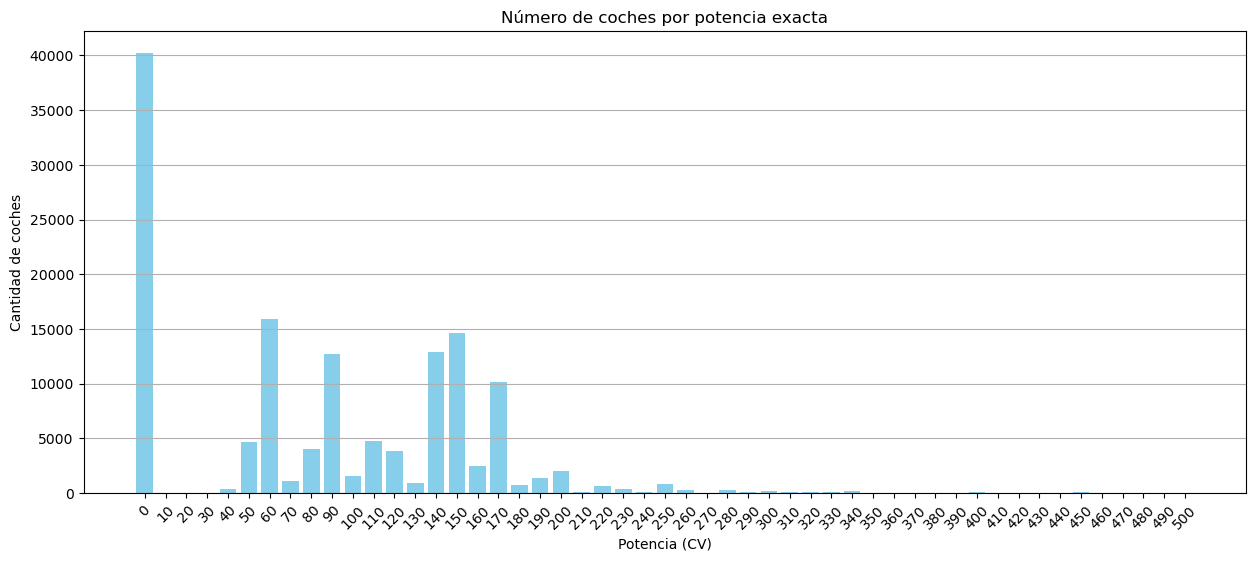

'Autos con 0 potencia: 40225'

'Autos entre 20 y 500 potencia: 313268'

In [18]:
# En el caso de power me dic eunta que hay muchos valores con 0  por lo cual decidi graficar para entender mejor los datos y 
# saber si valen la pena conservarlo o eliminarlos


# Definino los valores exactos que queremos analizar
valores = list(range(0, 501, 10))  # 0, 10, 20, ..., 500

# Contar cuántos coches tienen cada valor exacto
conteos = [df[df['Power'] == v].shape[0] for v in valores]

plt.figure(figsize=(15, 6))
plt.bar(valores, conteos, width=8, color='skyblue')
plt.xlabel('Potencia (CV)')
plt.ylabel('Cantidad de coches')
plt.title('Número de coches por potencia exacta')
plt.xticks(valores, rotation=45) 
plt.grid(axis='y')
plt.show()

display(f"Autos con 0 potencia: {(df['Power'] == 0).sum()}")  # valores anormales coches con potencia 0 que eliminare
display(f"Autos entre 20 y 500 potencia: {df[(df['Power'] >= 20) & (df['Power'] <= 500)].shape[0]}") # valores que si utilizare para el ML

In [19]:
# quiero revisar el porcentaje de datos nulos que tenemos para saber si vale la pena conservarlos o no
percent_null = df['VehicleType'].isna().mean()
print(f"Porcentaje de nulos en VehicleType: {percent_null:.2%}")

percent_null = df['Gearbox'].isna().mean()
print(f"Porcentaje de nulos en Gearbox: {percent_null:.2%}")

percent_null = df['Model'].isna().mean()
print(f"Porcentaje de nulos en Model: {percent_null:.2%}")

percent_null = df['FuelType'].isna().mean()
print(f"Porcentaje de nulos en FuelType: {percent_null:.2%}")

percent_null = df['NotRepaired'].isna().mean()
print(f"Porcentaje de nulos en NotRepaired: {percent_null:.2%}")


Porcentaje de nulos en VehicleType: 10.58%
Porcentaje de nulos en Gearbox: 5.60%
Porcentaje de nulos en Model: 5.56%
Porcentaje de nulos en FuelType: 9.28%
Porcentaje de nulos en NotRepaired: 20.08%


Notas:

Encontre varios datos en este proyecto para poder desarrollar mejor los Modelos futuros y trabajar con datos limpios lo que hare a continuacion sera:

-- Convertire a Datetime DateCrawled, DateCreated, LastSeen, para un mejor uso.

-- Price lo pasare como Float ya que los modelos de ML trabajan mejor con floats que con int. y ajustare el datset sin los autos con valor 0

-- En el caso de RegistrationYear recordar filtra valores imposibles (por ejemplo: antes de 1900 o después de 2025).

-- Eliminare las columnas Numbers of pictures y Postal Code ya que una esta llena de valores 0 y la otra tiene irrelevancia para el objetivo.

-- Eliminare todos los autos con potencia 0 esto puede ser ruido, falta de informacion y al final no me ayudan para el objetivo.

-- En el caso de los valores Nulos solo aplicare Unknown ya que los porcentajes de valores nulos son altos en algunos casos.



In [20]:
# Convertir a Datetime DateCrawled, DateCreated, LastSeen
df['DateCrawled'] = pd.to_datetime(df['DateCrawled'], dayfirst=True)
df['DateCreated'] = pd.to_datetime(df['DateCreated'], dayfirst=True)
df['LastSeen'] = pd.to_datetime(df['LastSeen'], dayfirst=True)

# Price de int a float
df['Price'] = df['Price'].astype(float)

# Filtramos el precio de los autos
df = df[df['Price'] > 0]

# Fultramos por fechas reales de registro
df = df[(df['RegistrationYear'] >= 1900) & (df['RegistrationYear'] <= 2025)]

# Eliminar Numbers of pictures y Postal Code
df.drop(columns=['NumberOfPictures','PostalCode'], inplace=True)

# Eliminar todos los autos con potencia 0 
df.drop(df[df['Power'] == 0].index , inplace=True)

# Aplicar unknown a las columnas nulas
for col in ['VehicleType','Gearbox','Model','FuelType','NotRepaired']:
    df[col] = df[col].fillna('unknown')




Notas : 

Ahora que limpiamos los datos voy a prepara los datos para poder entrenar los Modelos

In [21]:
# Lo primero es asignar los valores a Target y Features, Para entrenar modelos de ML
target = df['Price']  # lo que quieres predecir
features = df.drop(['Price', 'DateCrawled', 'DateCreated', 'LastSeen'], axis=1)

# En este caso sobreescribimo features ya que ML no entiende texto, por eso transformamos a variables binarias
features = pd.get_dummies(features, drop_first=True)

# Seleccionamos los parametros para entrenar nuestro modelo en 25% prueba y 75% entrenamiento
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=42)



## Entrenamiento del modelo 

#### Regresion Lineal

In [22]:
# Medir tiempo de entrenamiento
start = time.time() 

model_lr = LinearRegression()   # creo el modelo de regresion lineal
model_lr.fit(features_train,target_train) #uso fit para entrenar el modelo y aprende entre las variables features_train,target_train

predictions_lr = model_lr.predict(features_test)  #  Uso el modelo entrenado para predecir el precio de coches con los datos de prueba

rmse = root_mean_squared_error(target_test, predictions_lr) # Calculo el error cuadrático medio raíz (RMSE) entre los precios reales y los predichos
display(f"RMSE del modelo de Regresión Lineal: {rmse:.2f}") 

# Decidi sacarlo en porcentaje para entner mejor el rmse y lo qu eme dice el modelo
mean_price = df['Price'].mean()  # promedio del precio real para calcular el porcentaje

rmse_percent = (rmse / mean_price) * 100 # formula
display(f"RMSE relativo: {rmse_percent:.2f}%")

# Medir tiempo final
end = time.time()
time_lr = end - start
display(f"Tiempo de entrenamiento y predicción: {time_lr:.2f} segundos")


'RMSE del modelo de Regresión Lineal: 2774.56'

'RMSE relativo: 57.69%'

'Tiempo de entrenamiento y predicción: 3.75 segundos'

Notas de 1er Modelo Regresion Lineal:

Recordar si el RMSE es menor la prediccion es mas precisa
En este caso 57.69% es un valor bastante alto significa que el modelo no esta prediciendo con mucha precision aun
Es normal para las primeras etapas
Probare con los siguiente modelos, ajustare hiperparamentros y vere como cambia.



#### Bosque Aleatorio (Random Forest)

In [23]:
# Medir tiempo de entrenamiento
start = time.time()

# Creare y entrenare el modelo

model_rf = RandomForestRegressor(random_state=42, n_estimators=10, max_depth=30, max_features=0.5) # 100 estimadores es un numero equilibrado para obtener buenos resultados sin hacer al modelo lento 
model_rf.fit(features_train, target_train)

# Predecir el conjunto de prueba
predictions_rf = model_rf.predict(features_test)

# Calcular el RMSE para RF 
rmse_rf = root_mean_squared_error(target_test, predictions_rf)
display(f"RMSE del modelo de bosque aleatorio: {rmse_rf:.2f}")

# Calcular el RMSE de RF en Procentaje
rmse_rf_percent = (rmse_rf / mean_price) * 100
display(f"RMSE porcentual del modelo de bosque aleatorio: {rmse_rf_percent:.2f}%")

# Medir tiempo final
end = time.time()
time_rf = end - start
display(f"Tiempo de entrenamiento y predicción: {time_rf:.2f} segundos")



'RMSE del modelo de bosque aleatorio: 1589.34'

'RMSE porcentual del modelo de bosque aleatorio: 33.04%'

'Tiempo de entrenamiento y predicción: 34.16 segundos'

Notas Modelo de Bosque Aleatorio:

Modifique los hiperparametros hasta mejorar el RMSE y bajaste el error porcentual a 33.04%, aunque el tiempo de entrenamiento subió un poco (36 segundos). Eso indica que al aumentar la profundidad el modelo puede capturar mejor las relaciones complejas, pero también entrena un poco más lento.

Al obtener 33.04% — lo que muestra una mejora frente al modelo de regresión lineal.
Tiempo de Tiempo de entrenamiento: 36.21 segundos  mas lento que regresion lineal.

#### LightGBM

In [24]:

# Medir tiempo de entrenamiento
start = time.time()

# Crear el dataset para LightGBM
lgb_train = lgb.Dataset(features_train, label=target_train)
lgb_valid = lgb.Dataset(features_test, label=target_test, reference=lgb_train)

# Definir parámetros básicos
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': -1,
}

# Entrenar el modelo
model_lgb = lgb.train(params, lgb_train, num_boost_round=100)

# Predecir con el modelo entrenado
predictions_lgb = model_lgb.predict(features_test, num_iteration=model_lgb.best_iteration)

# Calcular RMSE absoluto
rmse_lgb = root_mean_squared_error(target_test, predictions_lgb)

# Calcular RMSE relativo (%)
mean_price = target.mean()
rmse_lgb_percent = (rmse_lgb / mean_price) * 100

# Medir tiempo final
end = time.time()
time_lgb = end - start

display(f"RMSE LightGBM: {rmse_lgb:.2f}")
display(f"RMSE relativo LightGBM: {rmse_lgb_percent:.2f}%")
display(f"Tiempo entrenamiento y predicción LightGBM: {time_lgb:.2f} segundos")


'RMSE LightGBM: 1688.11'

'RMSE relativo LightGBM: 35.10%'

'Tiempo entrenamiento y predicción LightGBM: 2.15 segundos'

Notas:

Buena precisión: El error promedio de predicción es de aproximadamente 1,688 euros por coche, lo cual es razonable para este tipo de dataset.

Error relativo bajo: Solo un 35.10% de error respecto al precio promedio, lo que es significativamente mejor que el modelo de Regresión Lineal (57%).

La velocidad de LightGBM es muy rápido comparado con el modelo de Bosque Aleatorio (que te tomó más de 30 segundos). Solo 2.31 segundos es ideal para una app como la que quiere Rusty Bargain.

#### CatBoost

In [25]:
# Medir tiempo de entrenamiento
start = time.time()

# Crear el modelo CatBoostRegressor
model_cb = CatBoostRegressor(
    iterations=100,        # número de árboles
    learning_rate=0.1,     # tasa de aprendizaje
    depth=6,               # profundidad máxima del árbol
    random_seed=42,
    verbose=0              # para no mostrar el proceso
)

# Entrenar el modelo
model_cb.fit(features_train, target_train)

# Predecir con el modelo entrenado
predictions_cb = model_cb.predict(features_test)

# Calcular RMSE absoluto
rmse_cb = root_mean_squared_error(target_test, predictions_cb)

# Calcular RMSE relativo (%)
mean_price = target_test.mean()
rmse_cb_percent = (rmse_cb / mean_price) * 100

# Medir tiempo final
end = time.time()
time_cb = end - start

display(f"RMSE CatBoost: {rmse_cb:.2f}")
display(f"RMSE relativo CatBoost: {rmse_cb_percent:.2f}%")
display(f"Tiempo entrenamiento y predicción CatBoost: {time_cb:.2f} segundos")


'RMSE CatBoost: 1826.73'

'RMSE relativo CatBoost: 37.99%'

'Tiempo entrenamiento y predicción CatBoost: 2.64 segundos'

## Análisis del modelo

In [28]:
df_modelos = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'LightGBM', 'CatBoost'],
    'RMSE Absoluto': [rmse, rmse_rf, rmse_lgb, rmse_cb],
    'RMSE procentaje(%)': [rmse_percent, rmse_rf_percent, rmse_lgb_percent, rmse_cb_percent],
    'Tiempo (segundos)': [time_lr, time_rf, time_lgb, time_cb]
})

display(df_modelos)

,Modelo,RMSE Absoluto,RMSE procentaje(%),Tiempo (segundos)
0,Regresión Lineal,2774.563586,57.685129,3.754109
1,Random Forest,1589.340129,33.043500,34.158637
2,LightGBM,1688.106231,35.096916,2.147233
3,CatBoost,1826.733854,37.991683,2.643754


# Lista de control

Escribe 'x' para verificar. Luego presiona Shift+Enter

- [x]  Jupyter Notebook está abierto
- [x]  El código no tiene errores- [x]  Las celdas con el código han sido colocadas en orden de ejecución- [x]  Los datos han sido descargados y preparados- [x]  Los modelos han sido entrenados
- [x]  Se realizó el análisis de velocidad y calidad de los modelos

#### Conclusiones debe venir esta explicacion que es lo que le importa al cliente

la calidad de la predicción
la velocidad de la predicción
el tiempo requerido para el entrenamiento